100%|██████████| 9.91M/9.91M [00:10<00:00, 903kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.79MB/s]


Epoch 0 | D Loss: 0.38593783024956646 | G Loss: 3.3886893770969246
Epoch 1 | D Loss: 0.008830175840550028 | G Loss: 7.238021288345109
Epoch 2 | D Loss: 0.033370839233305666 | G Loss: 10.664403320629713
Epoch 3 | D Loss: 0.48235222791780286 | G Loss: 7.6047325840891045
Epoch 4 | D Loss: 0.6451357298377735 | G Loss: 4.233145216126432
Epoch 5 | D Loss: 0.6893527777210228 | G Loss: 3.2487376841909086
Epoch 6 | D Loss: 0.6637362278918467 | G Loss: 3.256835518106977
Epoch 7 | D Loss: 0.5257003524346646 | G Loss: 3.4156271234504194
Epoch 8 | D Loss: 0.25410596212979825 | G Loss: 3.482893838048744
Epoch 9 | D Loss: 0.39341163775845883 | G Loss: 4.064114885035354
Epoch 10 | D Loss: 0.4350632421815319 | G Loss: 4.34604718131043
Epoch 11 | D Loss: 0.3590219810144352 | G Loss: 4.636273394261342
Epoch 12 | D Loss: 0.44160322911703764 | G Loss: 4.878078911604403
Epoch 13 | D Loss: 0.28086336880827 | G Loss: 5.520064940584748
Epoch 14 | D Loss: 0.2965936627088071 | G Loss: 4.467769919173804
Epoch 15 

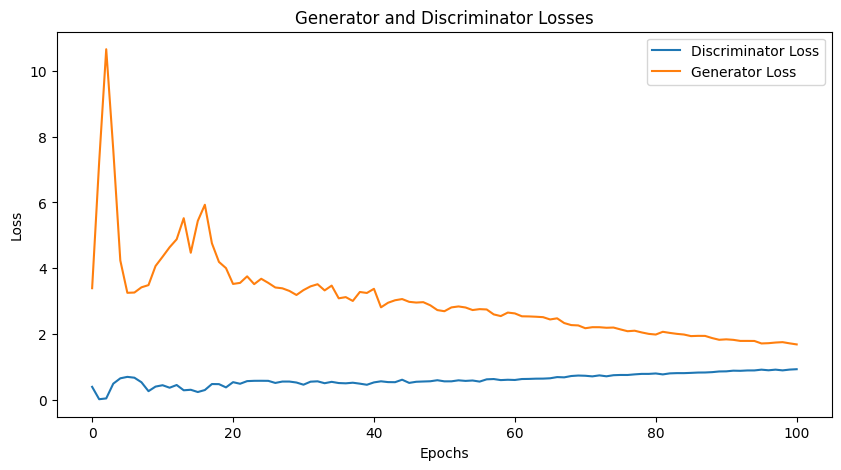

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

# Configuration
batch_size = 128
z_dim = 100
lr = 0.0002
epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(mnist, batch_size=batch_size, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

# Initialize models
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

# Loss and optimizers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

# Track loss
losses_G, losses_D = [], []

# Fixed noise for image generation
fixed_noise = torch.randn(64, z_dim, device=device)

# Image saving function
def save_generated(epoch):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()
    grid = make_grid(fake, nrow=8, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.title(f"Generated Images at Epoch {epoch}")
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis('off')
    plt.savefig(f"gan_epoch_{epoch}.png")
    plt.close()
    G.train()

# Training loop
for epoch in range(epochs + 1):
    loss_G_epoch, loss_D_epoch = 0, 0
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Train Discriminator
        z = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = G(z).detach()

        real_loss = criterion(D(real_imgs), real_labels)
        fake_loss = criterion(D(fake_imgs), fake_labels)
        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        z = torch.randn(batch_size, z_dim, device=device)
        generated_imgs = G(z)
        g_loss = criterion(D(generated_imgs), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        loss_D_epoch += d_loss.item()
        loss_G_epoch += g_loss.item()

    losses_D.append(loss_D_epoch / len(dataloader))
    losses_G.append(loss_G_epoch / len(dataloader))

    print(f"Epoch {epoch} | D Loss: {loss_D_epoch / len(dataloader)} | G Loss: {loss_G_epoch / len(dataloader)}")

    # Save sample images at specific epochs
    if epoch == 0 or epoch == 50 or epoch == 100:
        save_generated(epoch)

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(epochs + 1), losses_D, label='Discriminator Loss')
plt.plot(range(epochs + 1), losses_G, label='Generator Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Generator and Discriminator Losses')
plt.savefig("loss_plot.png")
plt.show()
